# Simple Machine Learning Project

This notebook trains a basic Machine Learning model using the Iris dataset.

The goal is to create a small reproducible ML project for the MLOps DEV → PROD workflow.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [3]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="target")

df = X.copy()
df["target"] = y
df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
print("Dataset shape:", df.shape)

print("\nFirst rows:")
display(df.head())

print("\nClass distribution:")
print(df["species"].value_counts())

print("\nBasic statistics:")
display(df.describe())

Dataset shape: (150, 6)

First rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Basic statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 120
Testing rows: 30


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [7]:
y_pred = model.predict(X_test)

print("Predictions created successfully.")
print("First predictions:", y_pred[:10])

Predictions created successfully.
First predictions: [0 2 1 1 0 1 0 0 2 1]


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.2f}")

Model accuracy: 0.90


In [9]:
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



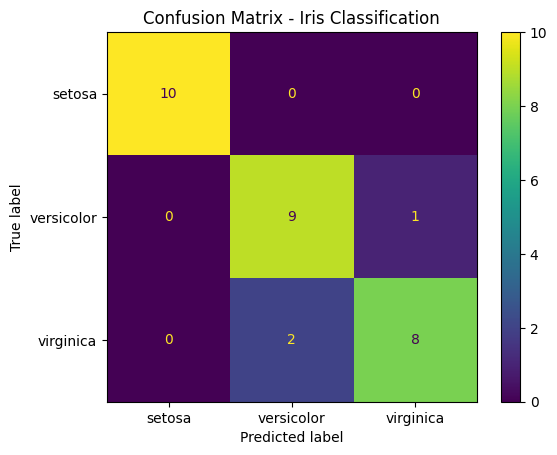

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - Iris Classification")
plt.show()

In [11]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
3,petal width (cm),0.437185
2,petal length (cm),0.431466
0,sepal length (cm),0.116349
1,sepal width (cm),0.015000


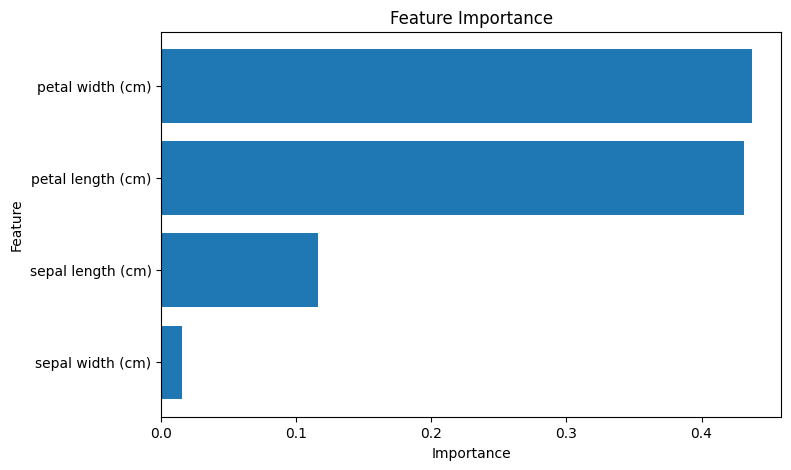

In [12]:
plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [13]:
print("Final conclusion:")
print("The model was trained and evaluated successfully.")
print(f"The final accuracy was {accuracy:.2f}.")
print("This project is ready to be reviewed by the Gatekeeper.")

Final conclusion:
The model was trained and evaluated successfully.
The final accuracy was 0.90.
This project is ready to be reviewed by the Gatekeeper.
